In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv(r'results\uploads\diabetes.csv')
df_clean = None
df_features = None
DATASET_COLUMNS = list(df_raw.columns)
NUMERIC_COLUMNS = df_raw.select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_COLUMNS = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
DATASET_SHAPE = df_raw.shape
ORIGINAL_NUMERIC_COLUMNS = NUMERIC_COLUMNS.copy()
ORIGINAL_CATEGORICAL_COLUMNS = CATEGORICAL_COLUMNS.copy()
print(f"Loaded {DATASET_SHAPE[0]} rows x {DATASET_SHAPE[1]} columns")


Loaded 1150 rows x 20 columns


In [ ]:

import json as _json

# Compute correlations for numeric columns
_corr_matrix = df_raw[NUMERIC_COLUMNS].corr() if len(NUMERIC_COLUMNS) > 1 else None
_top_correlations = []
if _corr_matrix is not None:
    for i, col1 in enumerate(NUMERIC_COLUMNS):
        for col2 in NUMERIC_COLUMNS[i+1:]:
            corr_val = abs(_corr_matrix.loc[col1, col2])
            if corr_val > 0.5:
                _top_correlations.append((col1, col2, round(corr_val, 3)))
    _top_correlations.sort(key=lambda x: x[2], reverse=True)
    _top_correlations = _top_correlations[:10]  # Top 10

# Compute skewness for numeric columns
_skewness = {}
for col in NUMERIC_COLUMNS:
    try:
        _skewness[col] = round(float(df_raw[col].skew()), 3)
    except:
        pass
_highly_skewed = [col for col, skew in _skewness.items() if abs(skew) > 1]

# Identify binary columns
_binary_columns = [col for col in df_raw.columns if df_raw[col].nunique() == 2]

# Identify potential target columns (binary or low cardinality categorical)
_potential_targets = [col for col in df_raw.columns if 2 <= df_raw[col].nunique() <= 10]

# Check class balance for potential targets (for class_imbalance skip decision)
_class_balance = {}
for col in _binary_columns + [c for c in _potential_targets if c not in _binary_columns]:
    try:
        counts = df_raw[col].value_counts(normalize=True)
        if len(counts) >= 2:
            majority_pct = float(counts.iloc[0] * 100)
            minority_pct = float(counts.iloc[1] * 100)
            _class_balance[col] = {
                'majority_pct': round(majority_pct, 1),
                'minority_pct': round(minority_pct, 1),
                'is_imbalanced': bool(majority_pct > 70)
            }
    except:
        pass

_profile = {
    'shape': list(df_raw.shape),
    'columns': list(df_raw.columns),
    'dtypes': df_raw.dtypes.astype(str).to_dict(),
    'numeric_columns': NUMERIC_COLUMNS,
    'categorical_columns': CATEGORICAL_COLUMNS,
    'missing_values': df_raw.isnull().sum().to_dict(),
    'missing_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1).to_dict(),
    'duplicates': int(df_raw.duplicated().sum()),
    'describe': df_raw.describe().round(2).to_dict(),
    'top_correlations': _top_correlations,
    'highly_skewed_columns': _highly_skewed,
    'skewness': _skewness,
    'binary_columns': _binary_columns,
    'potential_targets': _potential_targets,
    'class_balance': _class_balance,
}
print(_json.dumps(_profile))


{"shape": [1150, 20], "columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "dtypes": {"A": "int64", "B": "int64", "C": "int64", "D": "int64", "E": "int64", "F": "int64", "G": "int64", "H": "int64", "I": "float64", "J": "float64", "K": "float64", "L": "float64", "M": "float64", "N": "float64", "O": "float64", "P": "float64", "Q": "float64", "R": "float64", "S": "int64", "T": "int64"}, "numeric_columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "categorical_columns": [], "missing_values": {"A": 0, "B": 0, "C": 0, "D": 0, "E": 0, "F": 0, "G": 0, "H": 0, "I": 0, "J": 0, "K": 0, "L": 0, "M": 0, "N": 0, "O": 0, "P": 0, "Q": 0, "R": 0, "S": 0, "T": 0}, "missing_pct": {"A": 0.0, "B": 0.0, "C": 0.0, "D": 0.0, "E": 0.0, "F": 0.0, "G": 0.0, "H": 0.0, "I": 0.0, "J": 0.0, "K": 0.0, "L": 0.0, "M": 0.0, "N": 0.0, "O": 0.0, "P": 0.0, "Q": 0.0, "R": 0.0, "S": 0.0, "T": 0.0}, "duplica

In [ ]:
import pandas as pd

numeric_skewness = df_raw[NUMERIC_COLUMNS].skew().sort_values(ascending=False)
print('Skewness for Numeric Columns:\n', numeric_skewness)

print('\nDescriptive statistics for highly skewed columns (absolute skewness > 2):')
highly_skewed_cols = numeric_skewness[abs(numeric_skewness) > 2].index.tolist()
if highly_skewed_cols:
    print(df_raw[highly_skewed_cols].describe())
else:
    print('No columns with absolute skewness > 2.')


print('\nAnalyzing highly correlated columns:')
high_corr_pairs = [['C', 'D'], ['D', 'E'], ['E', 'F'], ['F', 'G'], ['C', 'E']]
for col1, col2 in high_corr_pairs:
    print(f'\nDescriptive statistics for {col1} and {col2}:')
    print(df_raw[[col1, col2]].describe())
    print(f'Correlation between {col1} and {col2}: {df_raw[col1].corr(df_raw[col2]):.3f}')

print('\nAnalyzing binary columns A, B, S, T:')
binary_cols = ['A', 'B', 'S', 'T']
for col in binary_cols:
    print(f'\nValue counts for {col}:')
    counts = df_raw[col].value_counts()
    print(counts)
    if col in ['A', 'B']:
        if len(counts) > 1 and counts.min() / counts.sum() < 0.1:
            print(f'Column {col} shows significant imbalance.')
        else:
            print(f'Column {col} does not show significant imbalance.')

Skewness for Numeric Columns:
 M    11.9593
N    11.5218
P     9.2287
O     8.3125
L     6.4232
K     2.9564
J     2.1343
I     1.6463
R     0.7919
C     0.7435
H     0.7214
S     0.6928
D     0.6246
G     0.5322
E     0.5319
F     0.4976
T    -0.1256
Q    -0.1893
B    -3.0574
A   -16.8893
dtype: float64

Descriptive statistics for highly skewed columns (absolute skewness > 2):
              M         N         P         O         L         K         J         B         A
count 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000
mean     0.5612    0.2125    0.0373    0.0857    1.8380    8.7107   23.1020    0.9183    0.9965
std      2.4851    1.0576    0.1790    0.3989    3.9246   11.5708   21.6069    0.2741    0.0589
min      0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000
25%      0.0000    0.0000    0.0000    0.0000    0.0819    1.2424    7.9441    1.0000    1.0000
50%      0.0223    0.0016    0.0000    0.00

These count plots illustrate the distribution and imbalance of columns 'A' and 'B', both showing a predominant single value.
This scatter plot visualizes the strong positive correlation between columns 'C' and 'D', where values tend to increase together.
This histogram displays the highly skewed distribution of column 'M', indicating a concentration of values at the lower end with a long tail to the right.


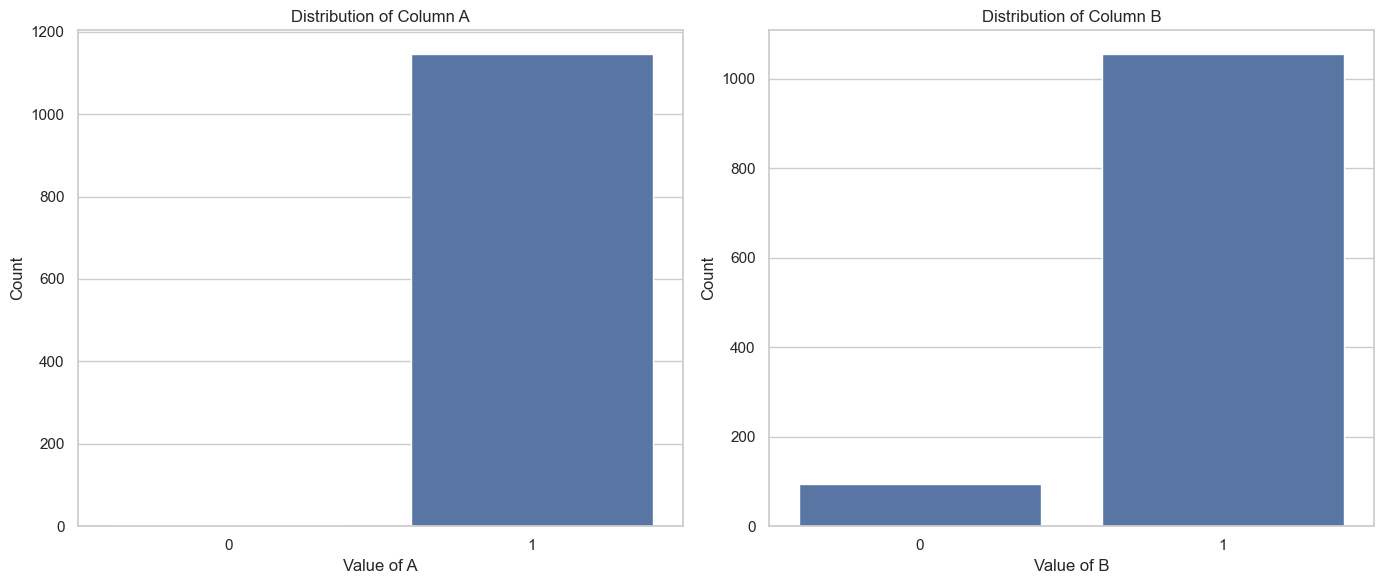

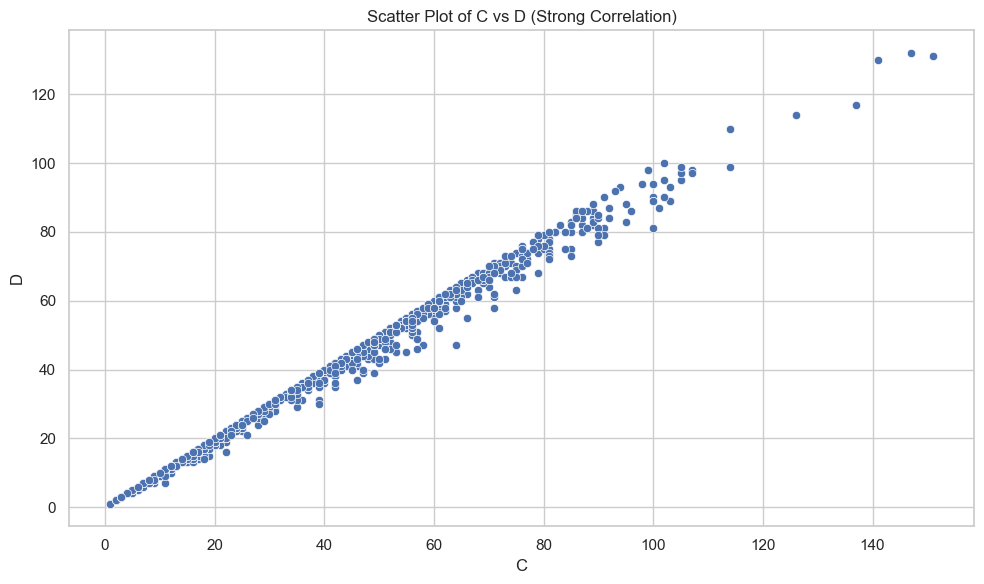

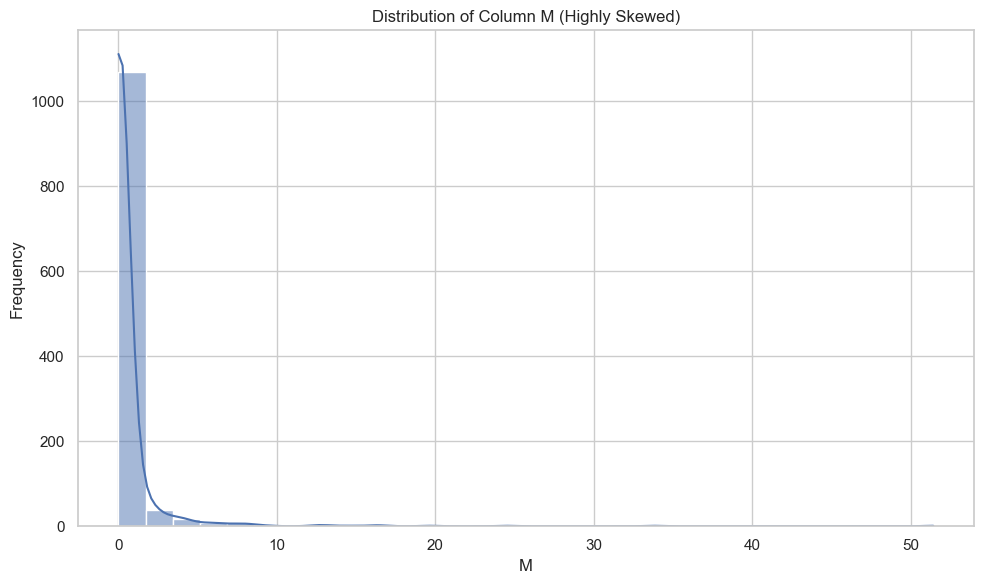

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count plots for 'A' and 'B'
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='A', data=df_raw, ax=axes[0])
axes[0].set_title('Distribution of Column A')
axes[0].set_xlabel('Value of A')
axes[0].set_ylabel('Count')

sns.countplot(x='B', data=df_raw, ax=axes[1])
axes[1].set_title('Distribution of Column B')
axes[1].set_xlabel('Value of B')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print("These count plots illustrate the distribution and imbalance of columns 'A' and 'B', both showing a predominant single value.")

# 2. Scatter plot for 'C' and 'D'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='C', y='D', data=df_raw)
plt.title('Scatter Plot of C vs D (Strong Correlation)')
plt.xlabel('C')
plt.ylabel('D')
plt.tight_layout()
plt.show()
print("This scatter plot visualizes the strong positive correlation between columns 'C' and 'D', where values tend to increase together.")

# 3. Histogram for 'M'
plt.figure(figsize=(10, 6))
sns.histplot(df_raw['M'], kde=True, bins=30)
plt.title('Distribution of Column M (Highly Skewed)')
plt.xlabel('M')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print("This histogram displays the highly skewed distribution of column 'M', indicating a concentration of values at the lower end with a long tail to the right.")